<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Jimmy, congratulations on completing your project!<br>

  My name is <b>Victor Camargo</b>
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I had the pleasure of reviewing your work.<br>

  <b>What you did well:</b><br>
  ✅ You implemented a clear and consistent preprocessing pipeline and applied the same normalization to train, test, and custom reviews.<br>
  ✅ You trained a TF-IDF + Logistic Regression model, used the shared evaluation routine, and met the project F1 requirement on the test set (F1 = 0.88).<br><br>

  <b>Final notes:</b><br>
  Yes, definitely try BERT in <b>Google Colab</b>, it’s a great model to experiment with. If you have access to a <b>GPU on your local machine</b>, that’s another excellent place to test it. It’s a powerful tool, just not always practical in constrained environments like this one.<br><br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved ✅</b>
  </div>

</div>

<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 1</b><br><br>
  Hello Jimmy, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b>
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <i>You can find my detailed feedback throughout the notebook, starting with comments labeled
  <b>“Reviewer’s comment – Iteration 1”</b>.</i><br>

  <b>What you did well:</b><br>
  ✅ You implemented a clear preprocessing pipeline and applied the same normalization to train, test, and custom reviews.<br>
  ✅ You trained a TF IDF plus Logistic Regression model that reached the project F1 requirement on the test set, and you used the shared evaluation routine to report metrics.<br>

  <b>Required fixes (only if red issues exist):</b><br>

  ⛔️ Please address the following issues to ensure the notebook runs correctly from top to bottom:<br>

  • Rearrange the <b>My Reviews</b> section so that the example reviews are defined <b>before</b> any prediction code.<br>
  • Remove or properly define any references to <b>undefined models or vectorizers</b> used in that section.<br>
  • Ensure all variables and models are initialized before they are used to avoid runtime errors.<br>

  <b>⛔️ Note on BERT usage:</b><br>
  • BERT-based models typically require a <b>GPU</b> to run efficiently.<br>
  • Running BERT on CPU is very slow and often impractical in this environment.<br>
  • Using only a small subset of the data to speed things up may lead to <b>overfitting</b> and unreliable results.<br>
    • For this project, I recommend <b>commenting out the BERT code</b> and not using it as part of your final solution, as it is currently <b>killing the kernel</b>.<br>


  <b>Project Status:</b><br>
  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
    <b>Needs Fixes</b>
  </div>

  <hr><b>Legend:</b><br>

  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Strong, correct solutions or good practices worth reusing.
  </div>

  <div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  Recommended improvements to strengthen your work.
  </div>

  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  Required fixes. The project cannot be approved until these are addressed.
  </div>

  <div class="alert alert-info" style="border-left: 7px solid blue; padding: 5px">
  <b>Student’s Comment</b><br>
  You may add your own notes or explanations in a <b>Markdown cell</b> using:<br>
  <code>&lt;div class="alert alert-info" style="border-left: 7px solid blue"&gt;&lt;b&gt;Student’s Comment&lt;/b&gt;&lt;/div&gt;</code>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom and display their outputs.<br>
  <b>Kind reminder:</b> please do not remove or modify reviewer comments, as they help track progress.<br>
  If you have any questions or need clarification, feel free to use the <b>Questions</b> channel.

</div>

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import nltk
import torch
import transformers
import spacy
import sklearn.metrics as metrics

from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from nltk.corpus import stopwords as nltk_stopwords
from lightgbm import LGBMClassifier

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

sns.set() # Using sns.set() to apply seaborn's default styling

In [4]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()


## Load Data

In [6]:
df_reviews = pd.read_csv('/content/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

## EDA

Let's check the number of movies and reviews over years.

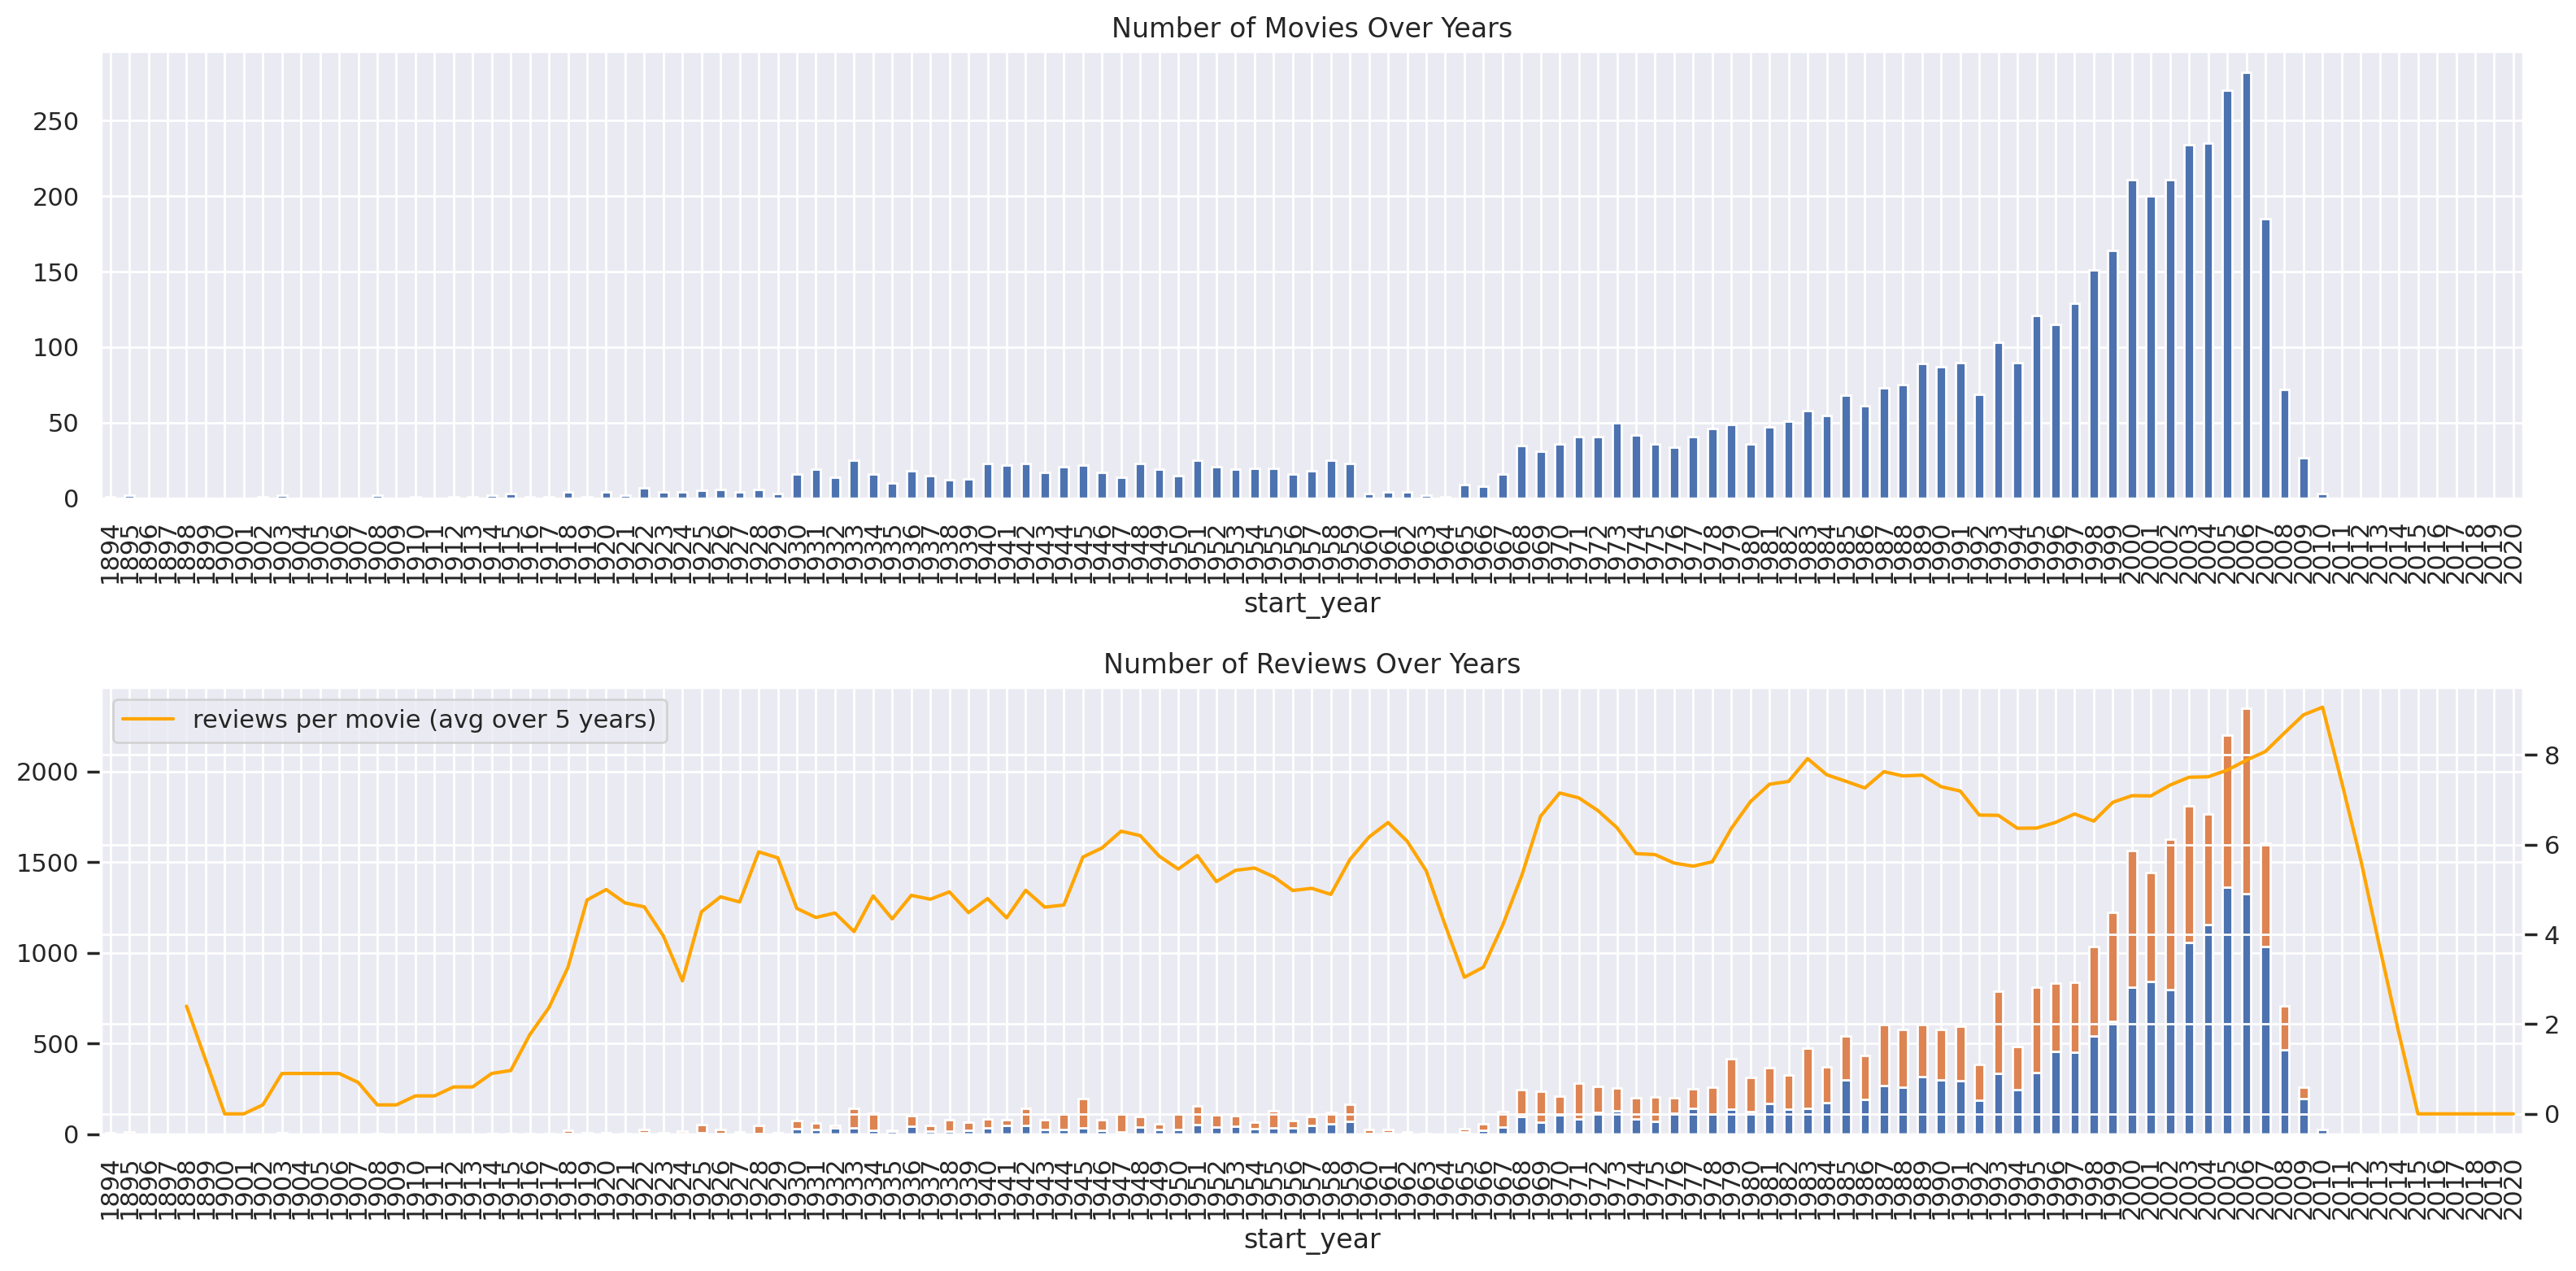

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

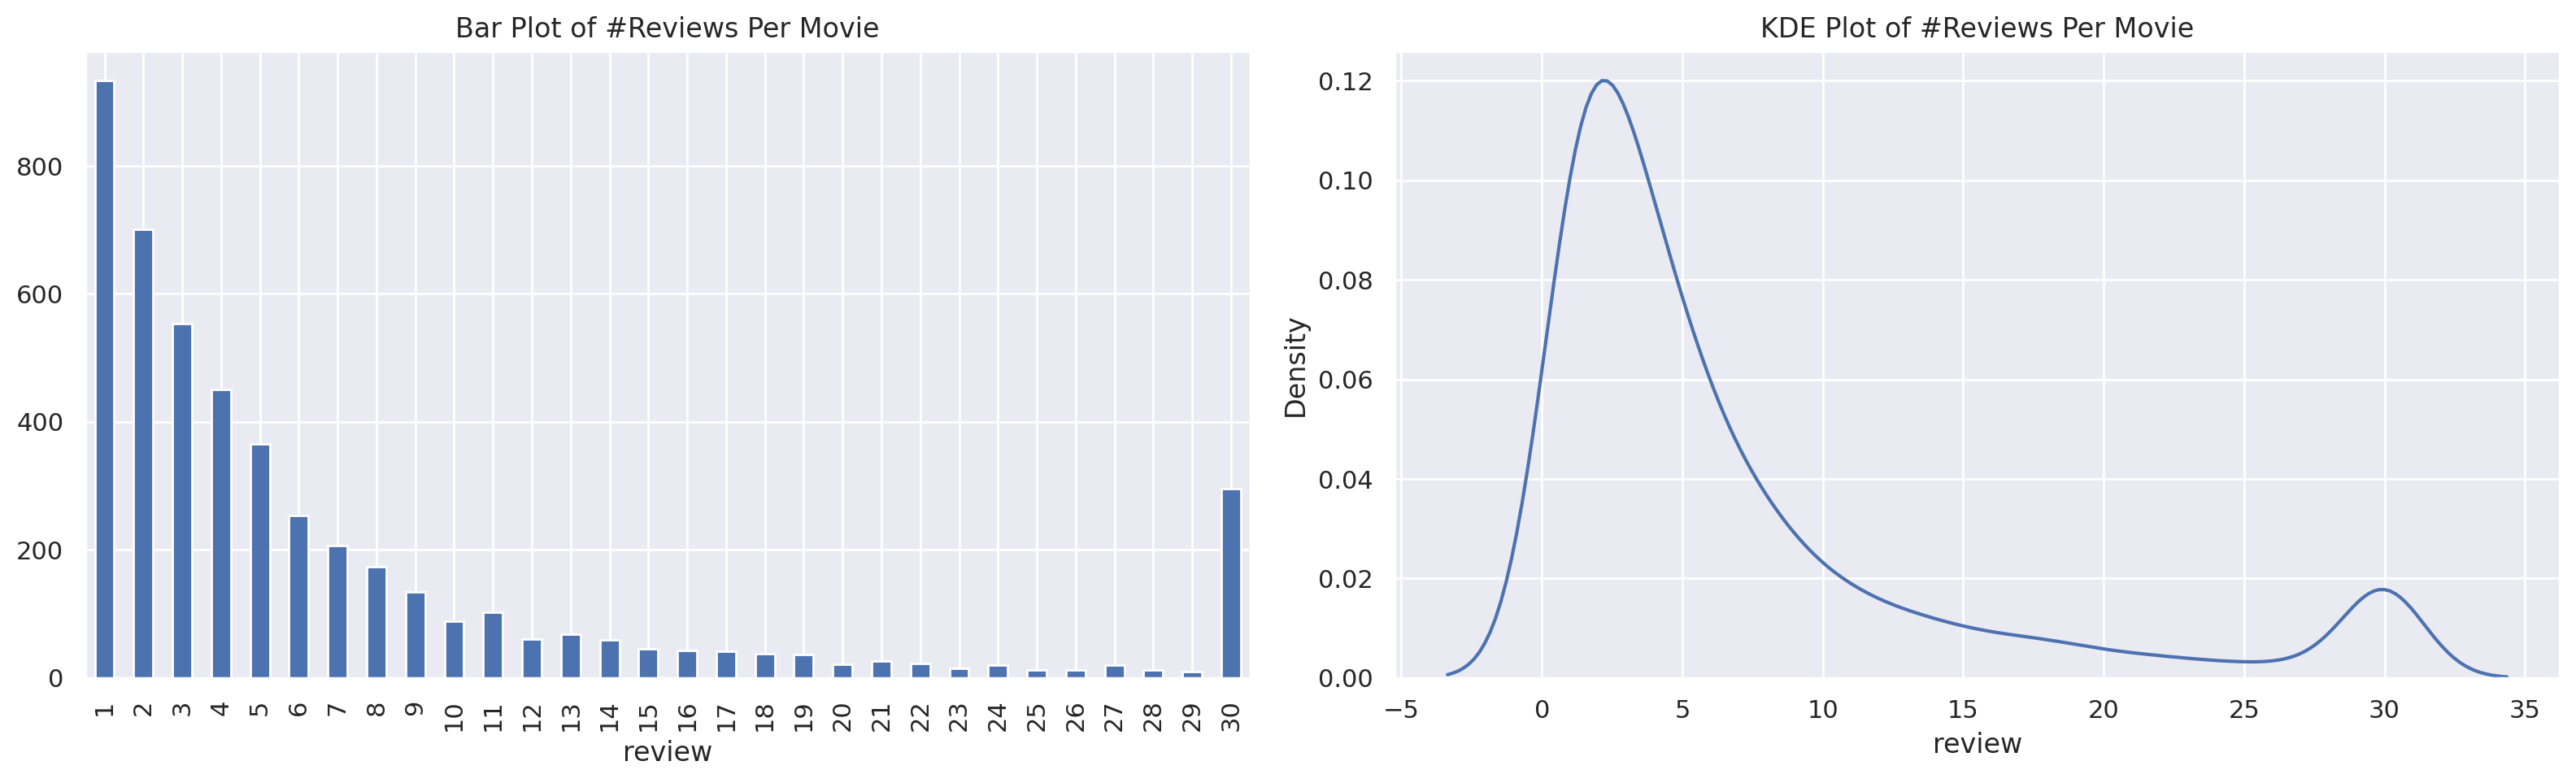

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [9]:
df_reviews['pos'].value_counts()

,count
pos,
0.0,17349
1.0,16675


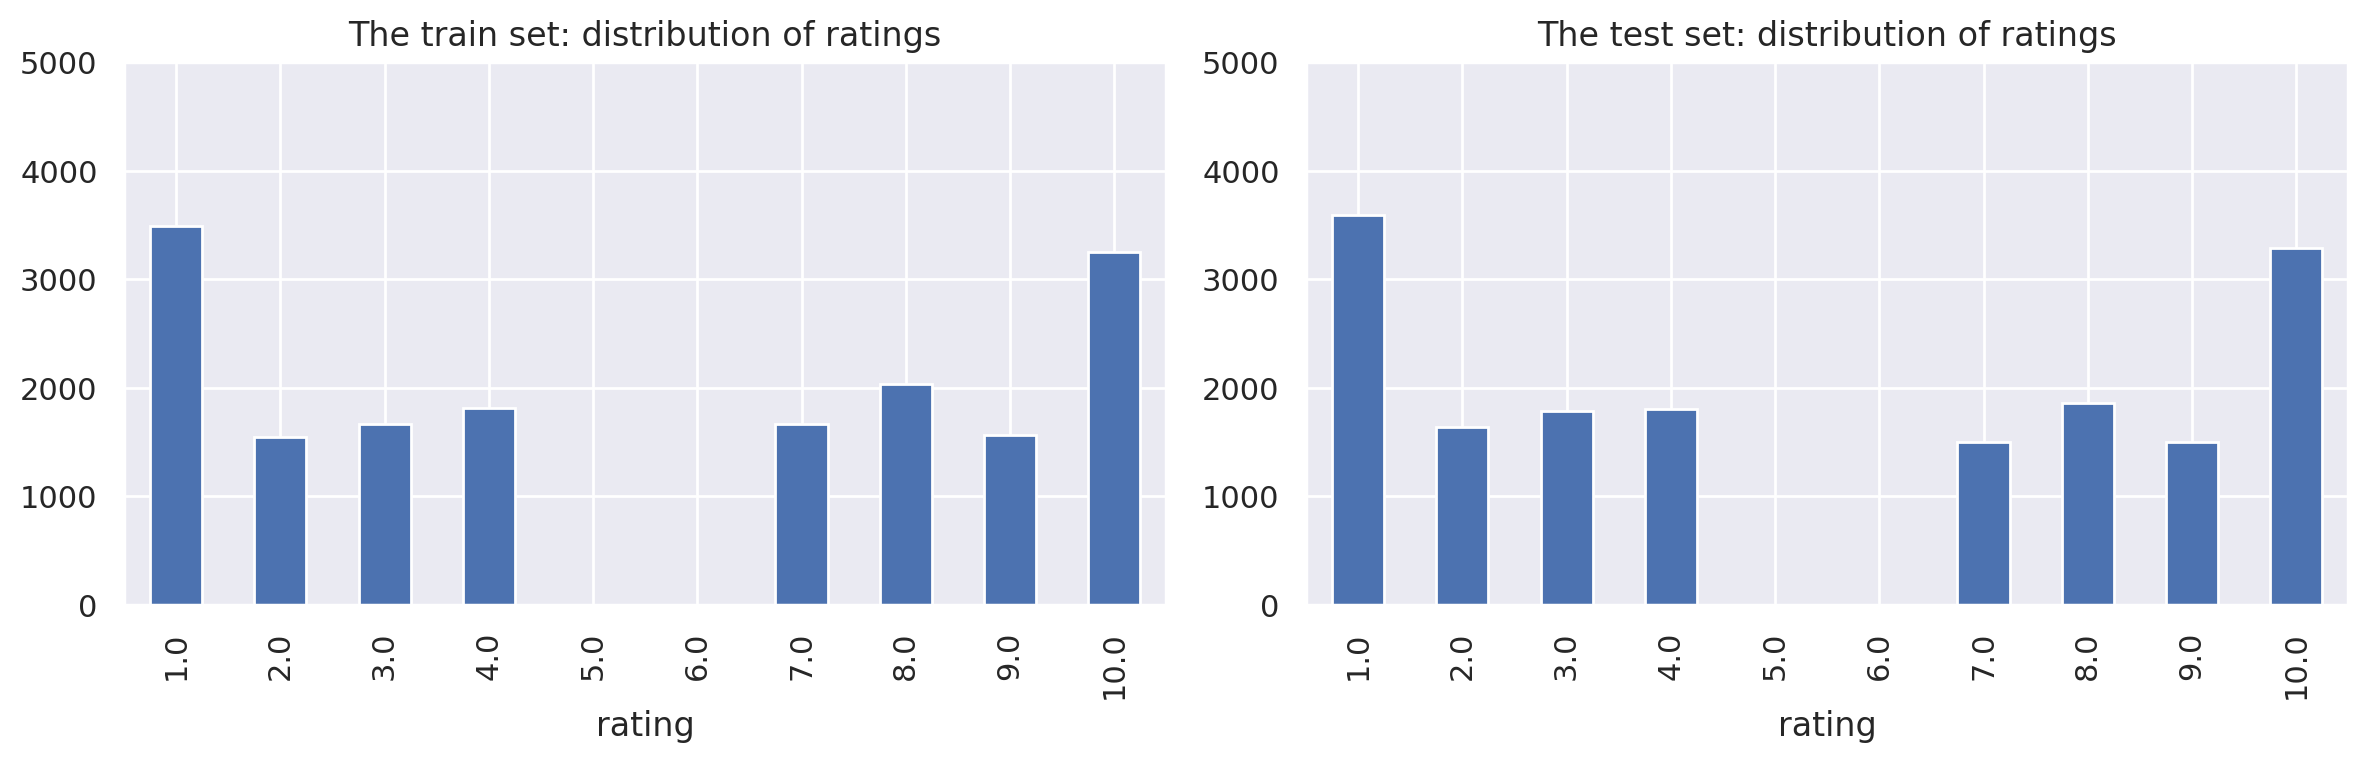

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/tmp/ipykernel_3656/2300874005.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_3656/2300874005.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/tmp/ipykernel_3656/2300874005.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_3656/2300874005.py:31: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update yo

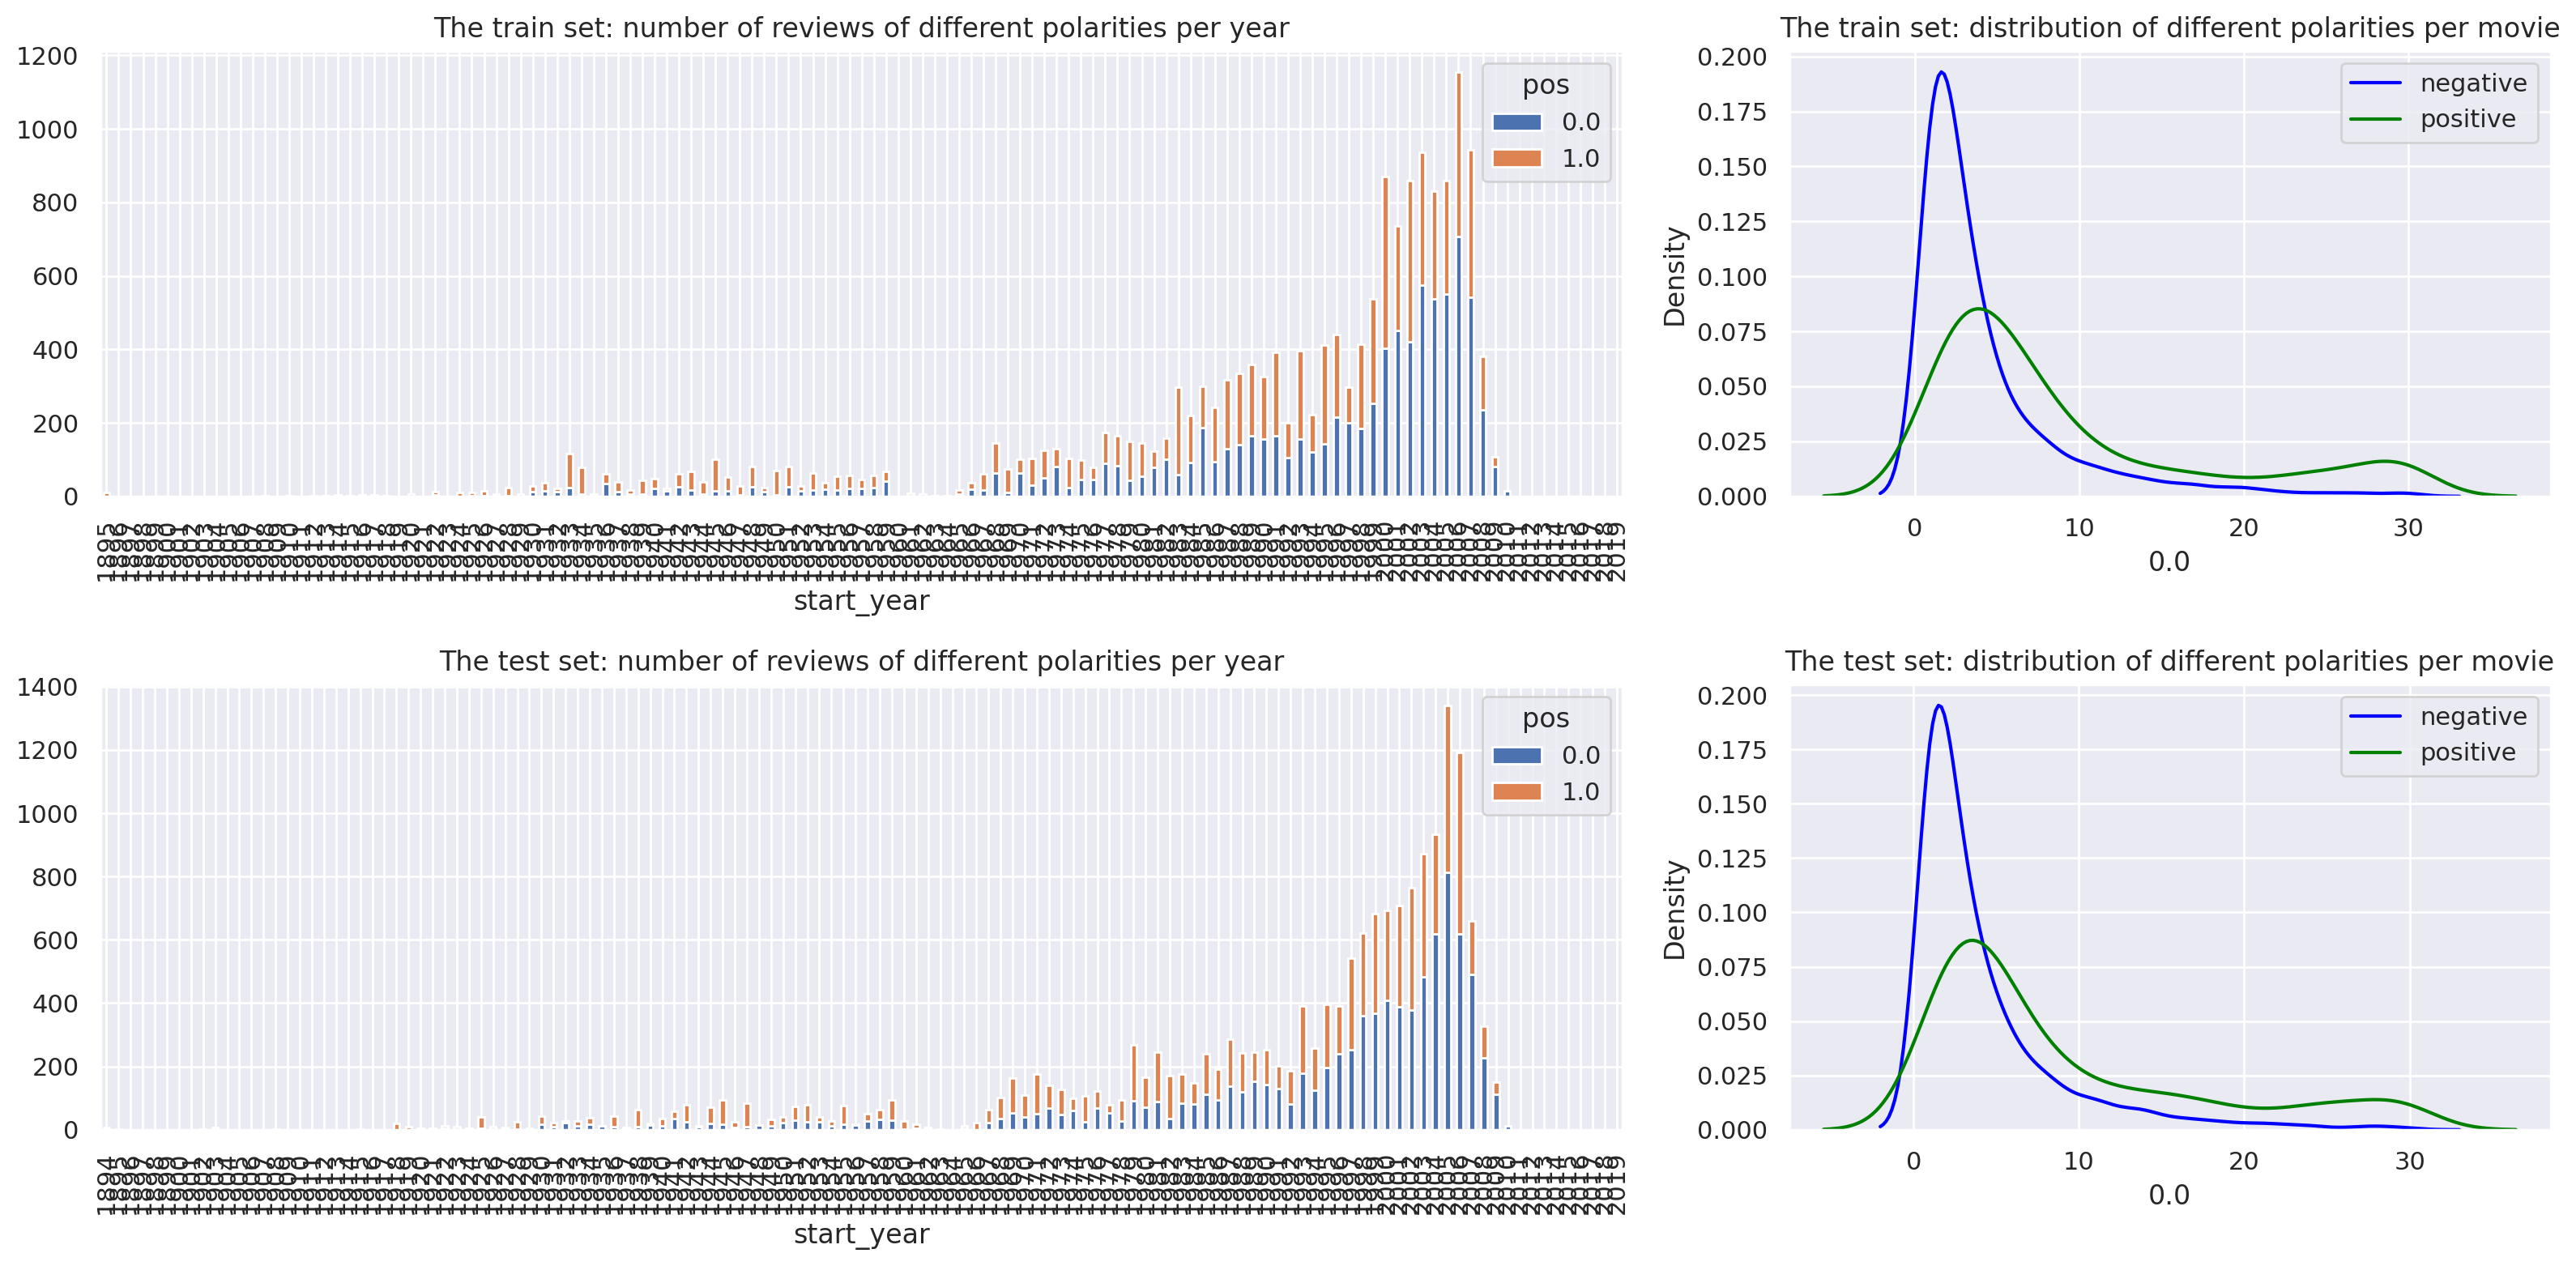

In [11]:

fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [12]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        eval_stats[type] = {}
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        color = 'blue' if type == 'train' else 'green'

        # F1 Score Plot
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title('F1 Score')

        # ROC Plot
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title('ROC Curve')

        # PRC Plot
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title('PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats).round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    print(df_eval_stats)

## Normalization

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-zA-Z']", " ", text)
    return " ".join(text.split())



We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [14]:
df_reviews['review_norm'] = df_reviews['review'].apply(clean_text)

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Good job creating a concise text normalization function and applying it to the dataset. The same cleaning is reused for train and test which keeps the pipeline consistent. This consistency is important for reliable evaluation and for applying the pipeline to custom reviews.
</div>

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [15]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(17050, 18)
(16974, 18)


## Working with models

### Model 0 - Constant

In [16]:
nltk.download('stopwords')
stop_words = list(set(nltk_stopwords.words('english')))
tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stop_words, max_features=5000)

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


          train  test
Accuracy    0.5  0.52
F1          0.0  0.00
APS         0.5  0.48
ROC AUC     0.5  0.50


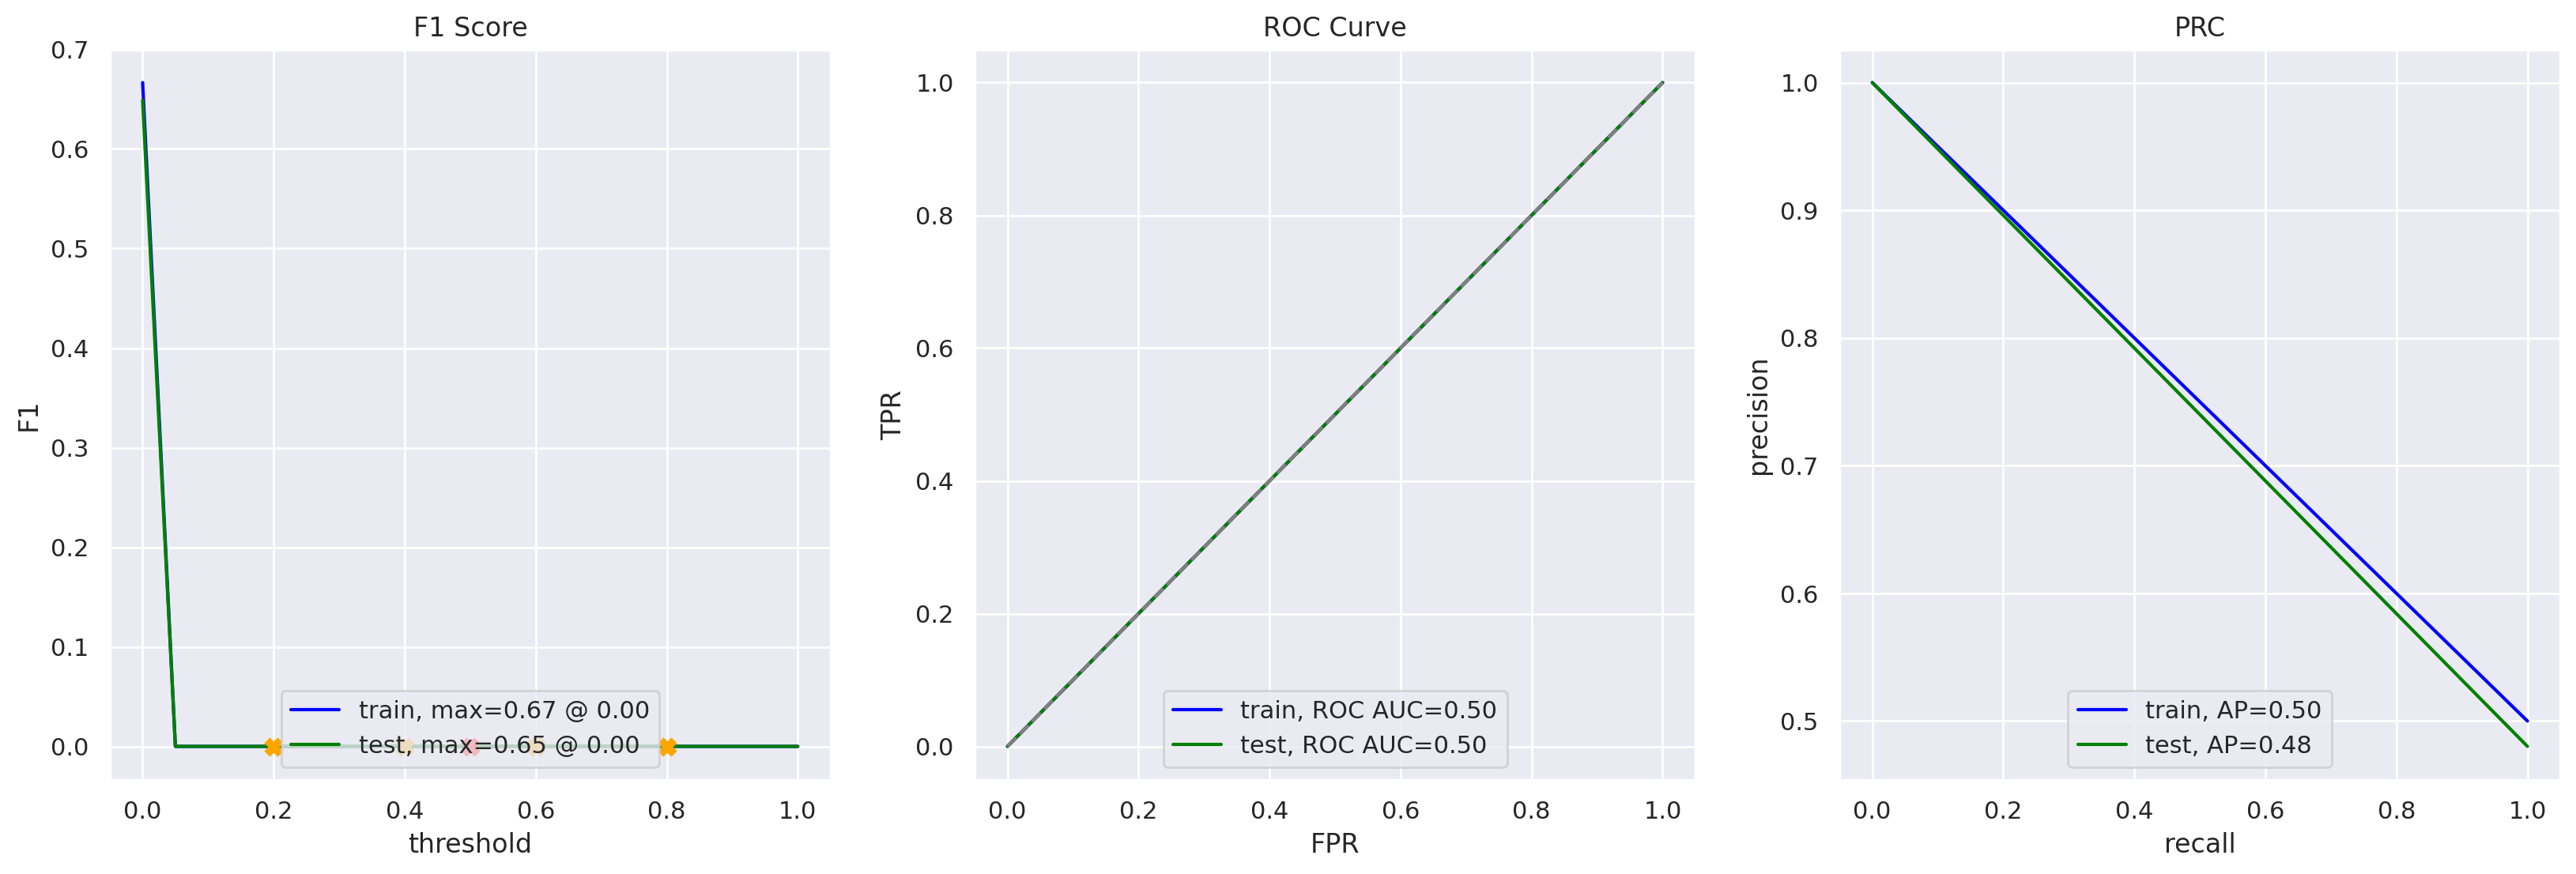

In [17]:
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)
model_0.fit(train_features_1, train_target)

# Evaluate using standard function
evaluate_model(model_0, train_features_1, train_target, test_features_1, test_target)

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [18]:

model_1 = LogisticRegression(solver='liblinear', random_state=42)
model_1.fit(train_features_1, train_target)

LogisticRegression(random_state=42, solver='liblinear')

          train  test
Accuracy   0.92  0.88
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


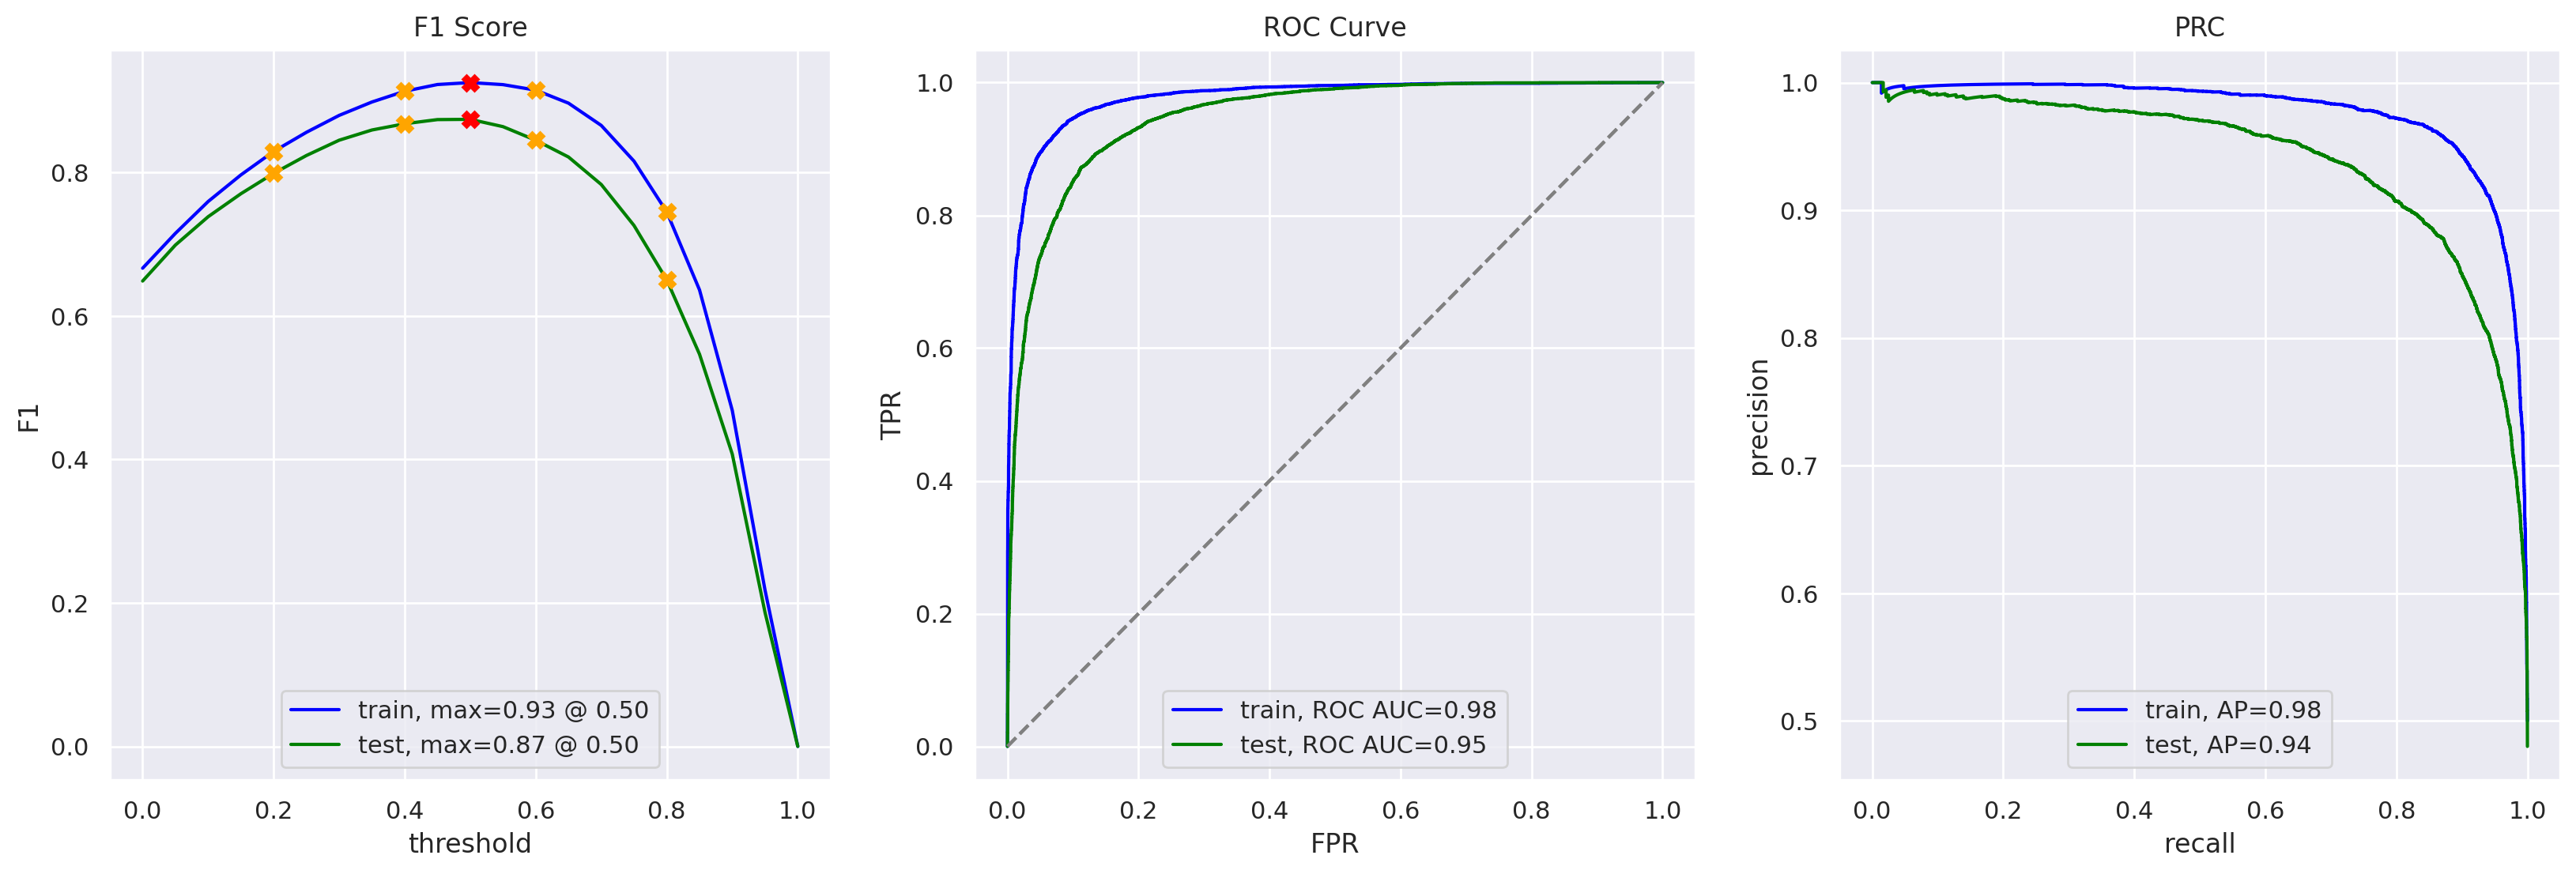

In [19]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Well done training the TF IDF plus Logistic Regression model and evaluating it with the shared routine. The model reaches an F1 of 0.88 on the test set which satisfies the project requirement. The evaluate_model function is used correctly to compare train and test results.
</div>

### Model 3 - spaCy, TF-IDF and LR

In [20]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def text_preprocessing_3(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]
    return ' '.join(tokens)

In [21]:
# Lemmatizing
print("Lemmatizing train set...")
train_norm_3 = df_reviews_train['review_norm'].apply(text_preprocessing_3)
print("Lemmatizing test set...")
test_norm_3 = df_reviews_test['review_norm'].apply(text_preprocessing_3)
print("Lemmatization complete!")

Lemmatizing train set...
Lemmatizing test set...
Lemmatization complete!


<div class="alert alert-info" style="border-left: 7px solid blue">
    <b>Student’s Comment:</b><br>
    I decided to use .apply() since the kernel kept crashing. </b></div>


In [22]:

tfidf_vectorizer_3 = TfidfVectorizer(stop_words=stop_words, max_features=5000)
train_features_3 = tfidf_vectorizer_3.fit_transform(train_norm_3)
test_features_3 = tfidf_vectorizer_3.transform(test_norm_3)

model_3 = LogisticRegression(solver='liblinear', random_state=42)
model_3.fit(train_features_3, train_target)


LogisticRegression(random_state=42, solver='liblinear')

          train  test
Accuracy   0.92  0.87
F1         0.92  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


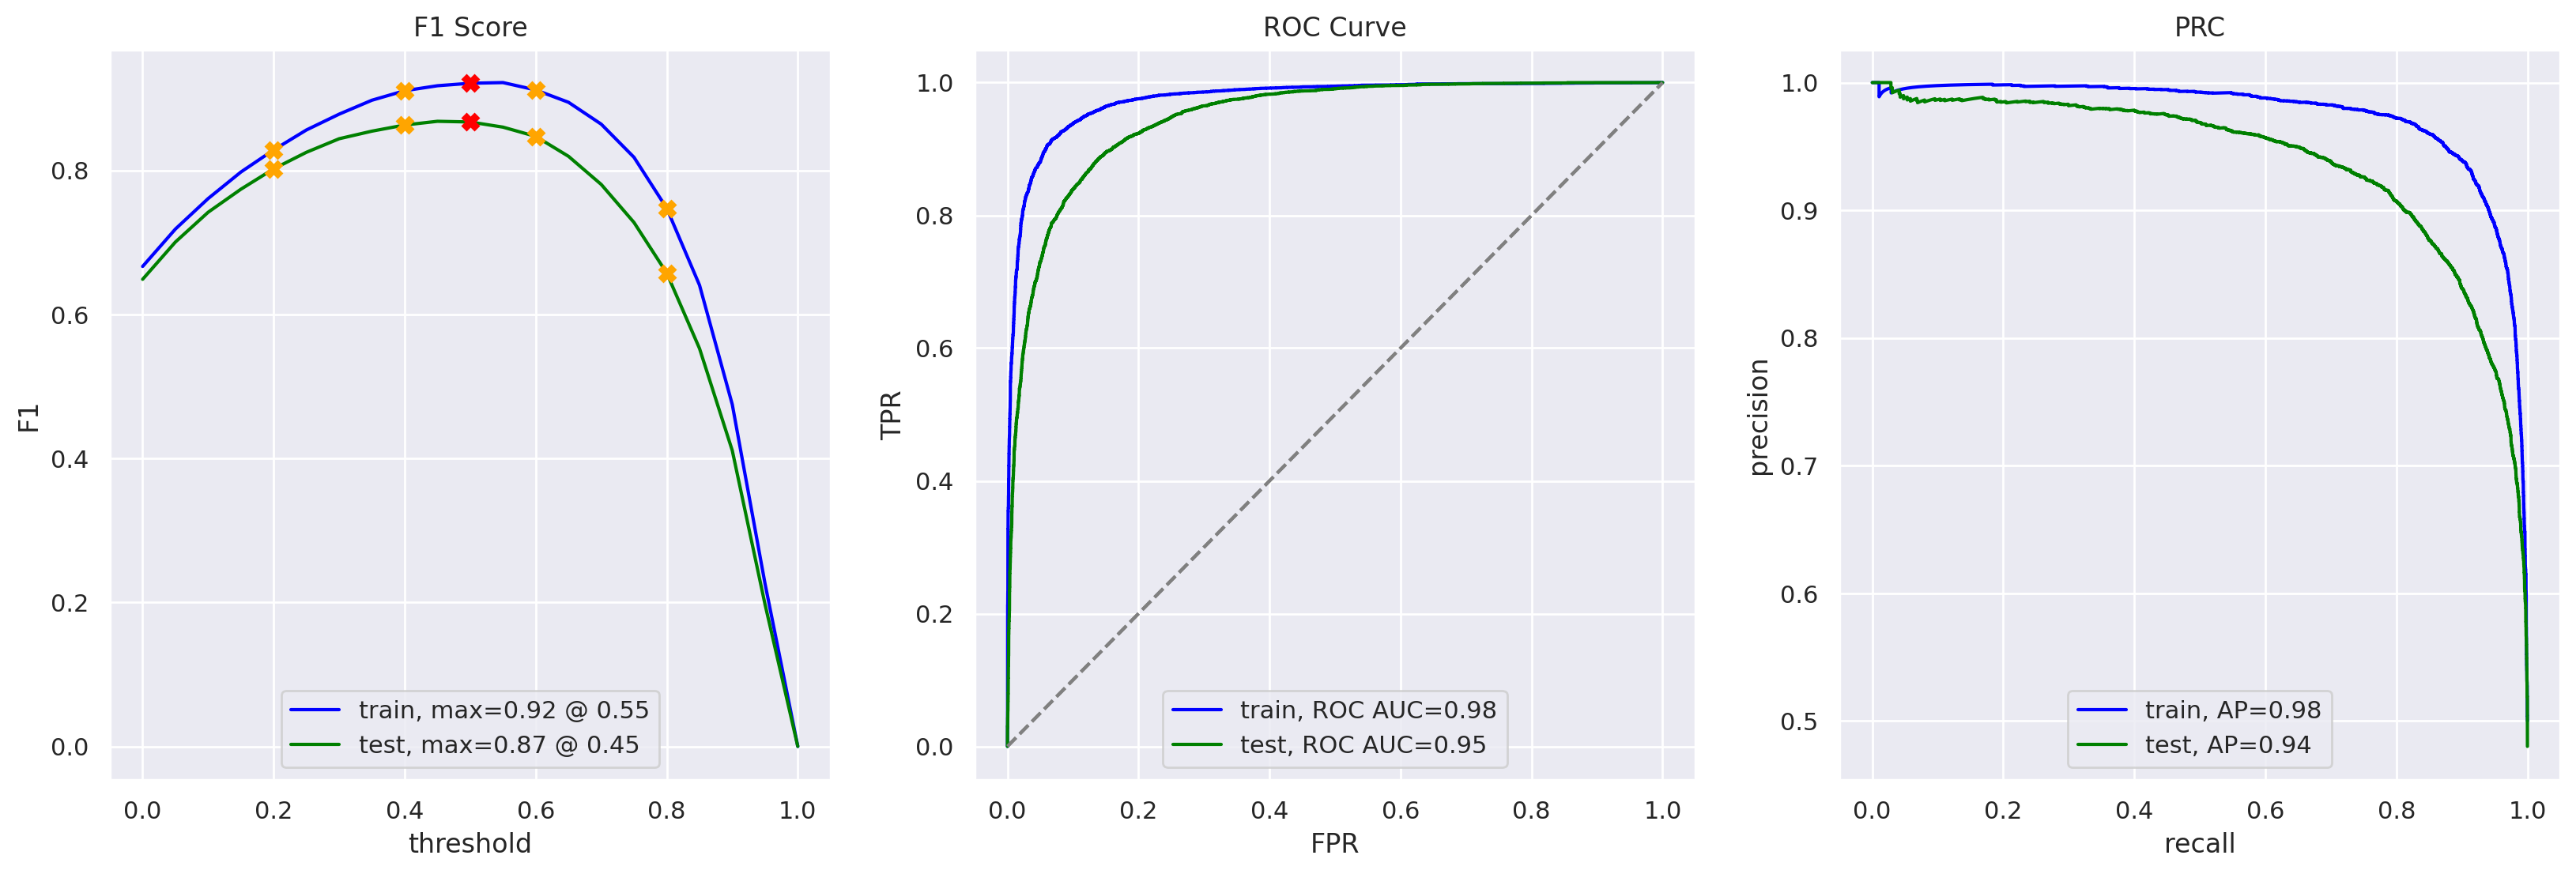

In [23]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Model 4 - spaCy, TF-IDF and LGBMClassifier

[LightGBM] [Info] Number of positive: 8525, number of negative: 8525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.073884 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319086
[LightGBM] [Info] Number of data points in the train set: 17050, number of used features: 4963
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


          train  test
Accuracy   0.92  0.85
F1         0.92  0.85
APS        0.98  0.93
ROC AUC    0.98  0.93


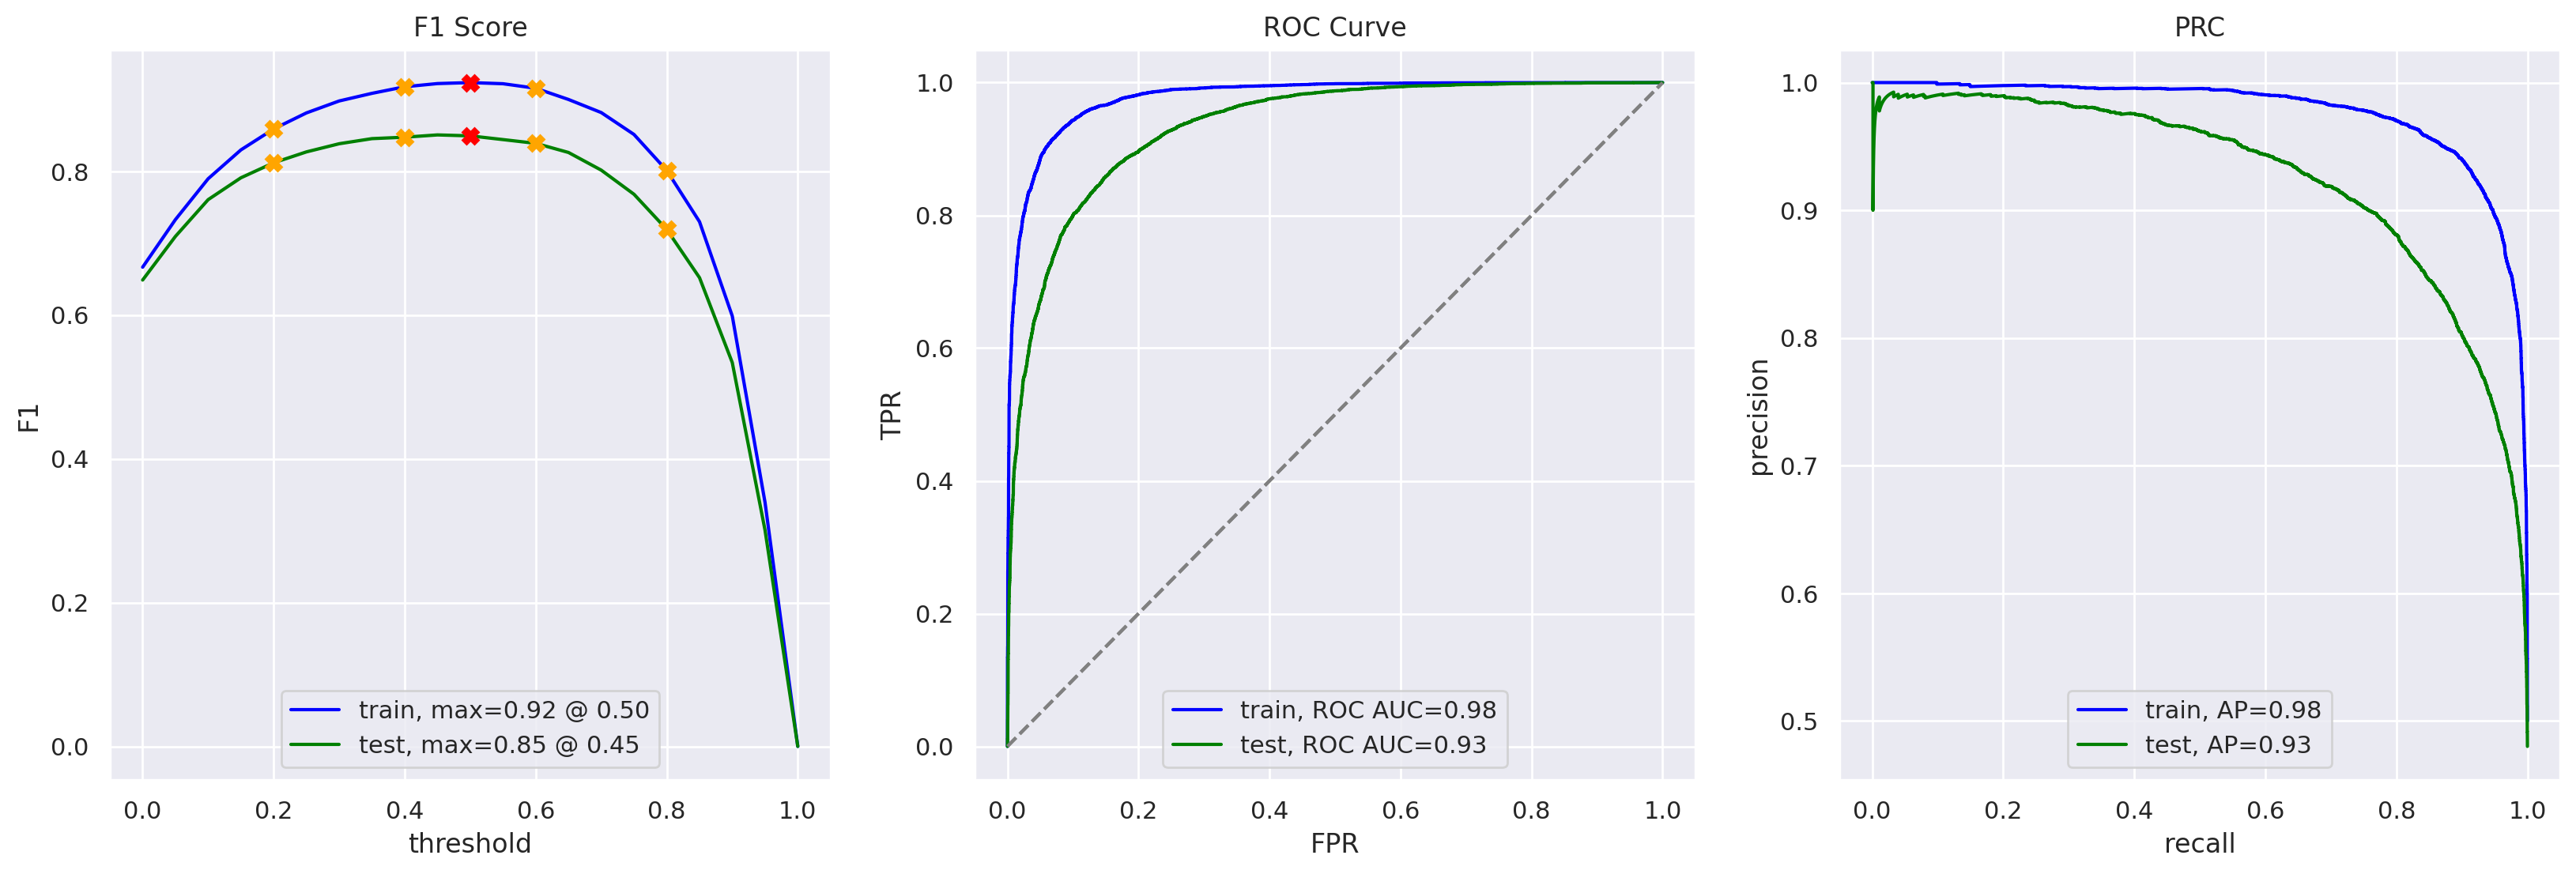

In [24]:
# Model 4 - Regularized and Faster
model_4 = LGBMClassifier(
    n_estimators=100,      # Reduced from 200 to speed it up
    learning_rate=0.1,
    reg_alpha=1.0,         # Stronger L1 regularization
    reg_lambda=1.0,        # Stronger L2 regularization
    random_state=42
)
model_4.fit(train_features_3, train_target)
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


          train  test
Accuracy   0.92  0.85
F1         0.92  0.85
APS        0.98  0.93
ROC AUC    0.98  0.93


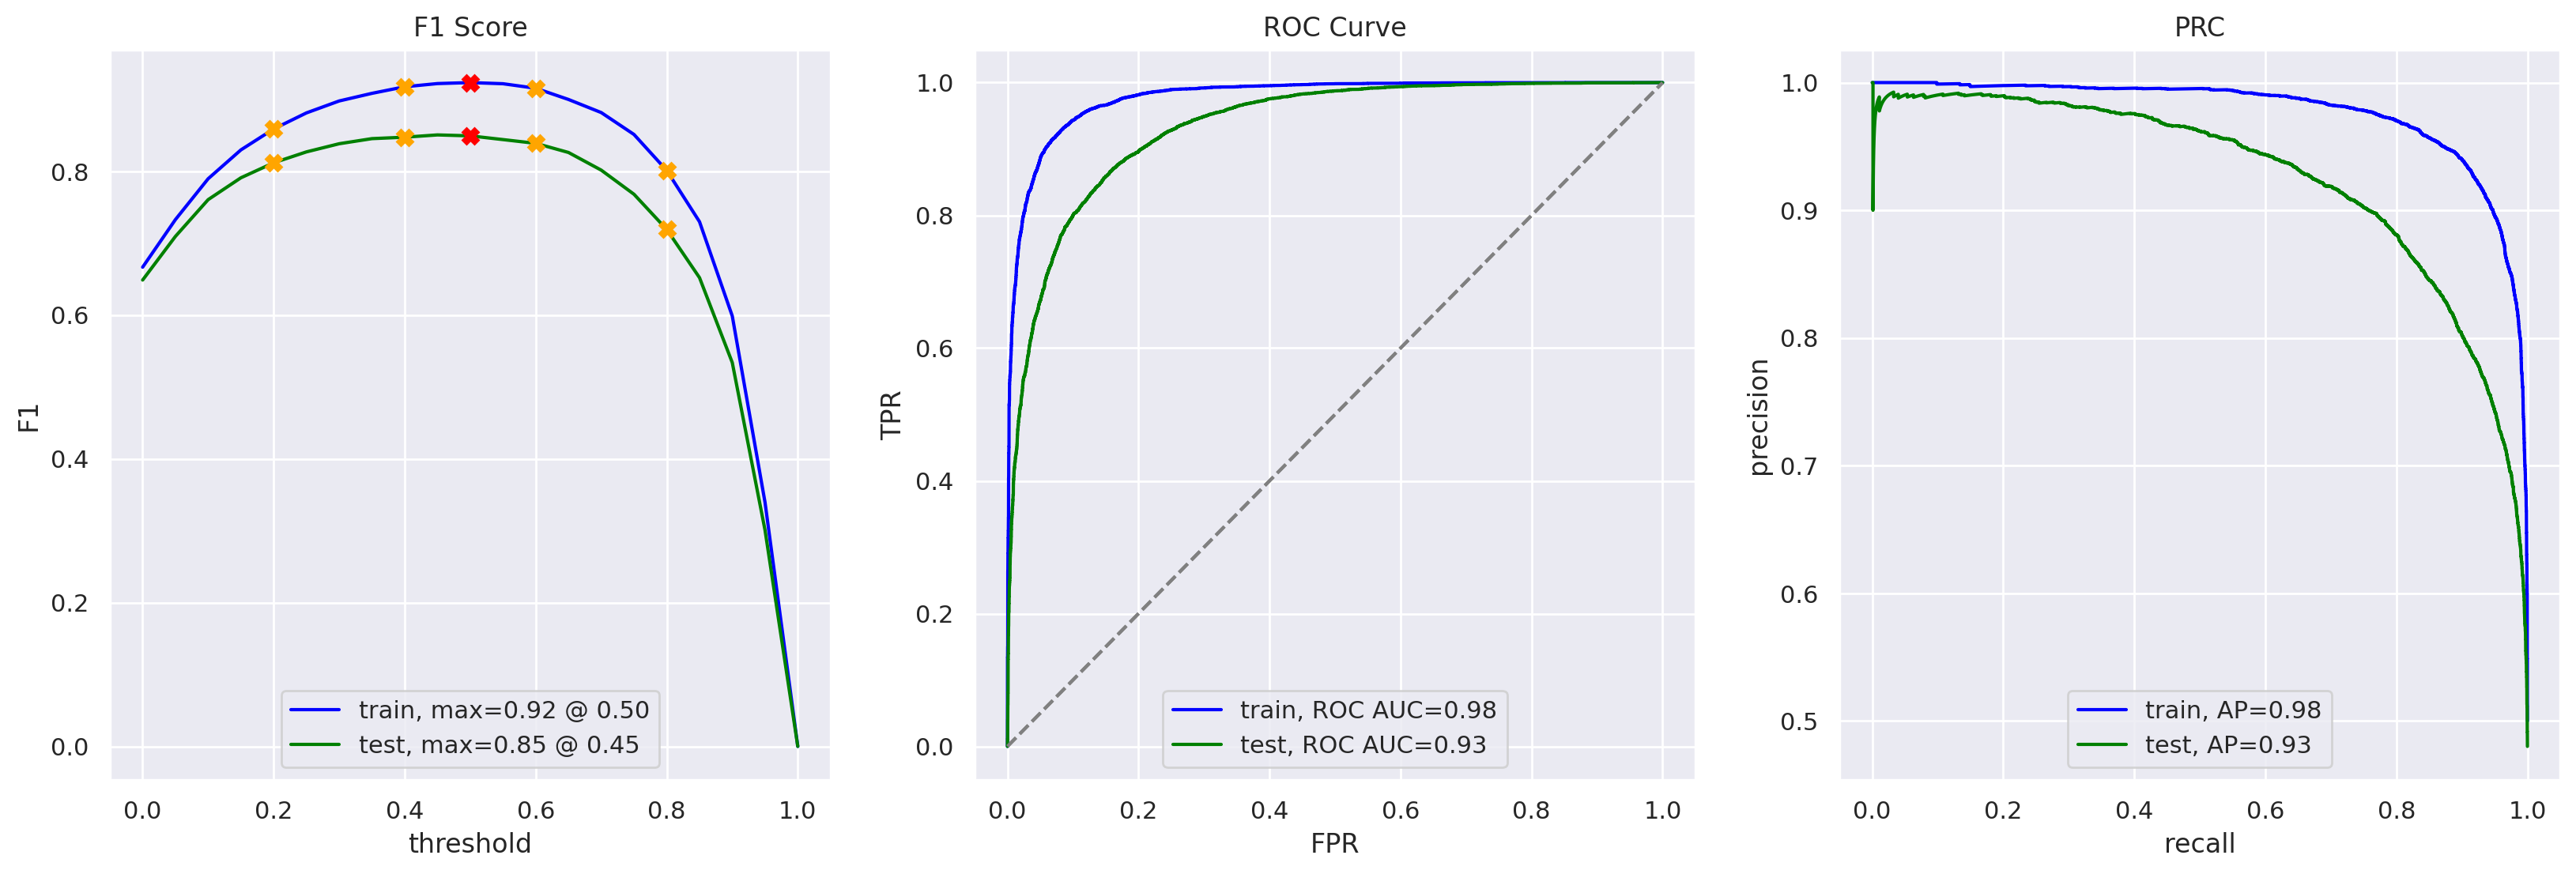

In [25]:
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  The LightGBM model shows much higher train F1 than test F1 which may indicate some overfitting. Please add a short note in the conclusions commenting on this gap and why you still prefer the recommended model for production, or consider adding a brief regularization note if you want to reduce overfitting.
</div>


<div class="alert alert-info" style="border-left: 7px solid blue"><b>Student’s Comment:</b><br>
I decreased the n_estimator to 100 to prevent the kernel to crash and to get faster results since I'm running on CPU. </div>

###  Model 9 - BERT

In [26]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = transformers.BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=32, force_device=None, disable_progress_bar=False):
    ids_list = []
    attention_mask_list = []

    for text in tqdm(texts, disable=disable_progress_bar):
        encoded = tokenizer(text, add_special_tokens=True, max_length=max_length,
                                        padding='max_length', truncation=True, return_attention_mask=True)
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])

    device = torch.device(force_device) if force_device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_bert.to(device)

    embeddings = []
    for i in range(math.ceil(len(ids_list)/batch_size)):
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)

        with torch.no_grad():
            model_bert.eval()
            batch_embeddings = model_bert(input_ids=ids_batch, attention_mask=mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [30]:
# updating to use GPU(T4)
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'].iloc[:400])
test_features_9 = BERT_text_to_embeddings(df_reviews_test['review_norm'].iloc[:400])

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

          train  test
Accuracy   1.00  0.80
F1         0.99  0.79
APS        1.00  0.89
ROC AUC    1.00  0.89


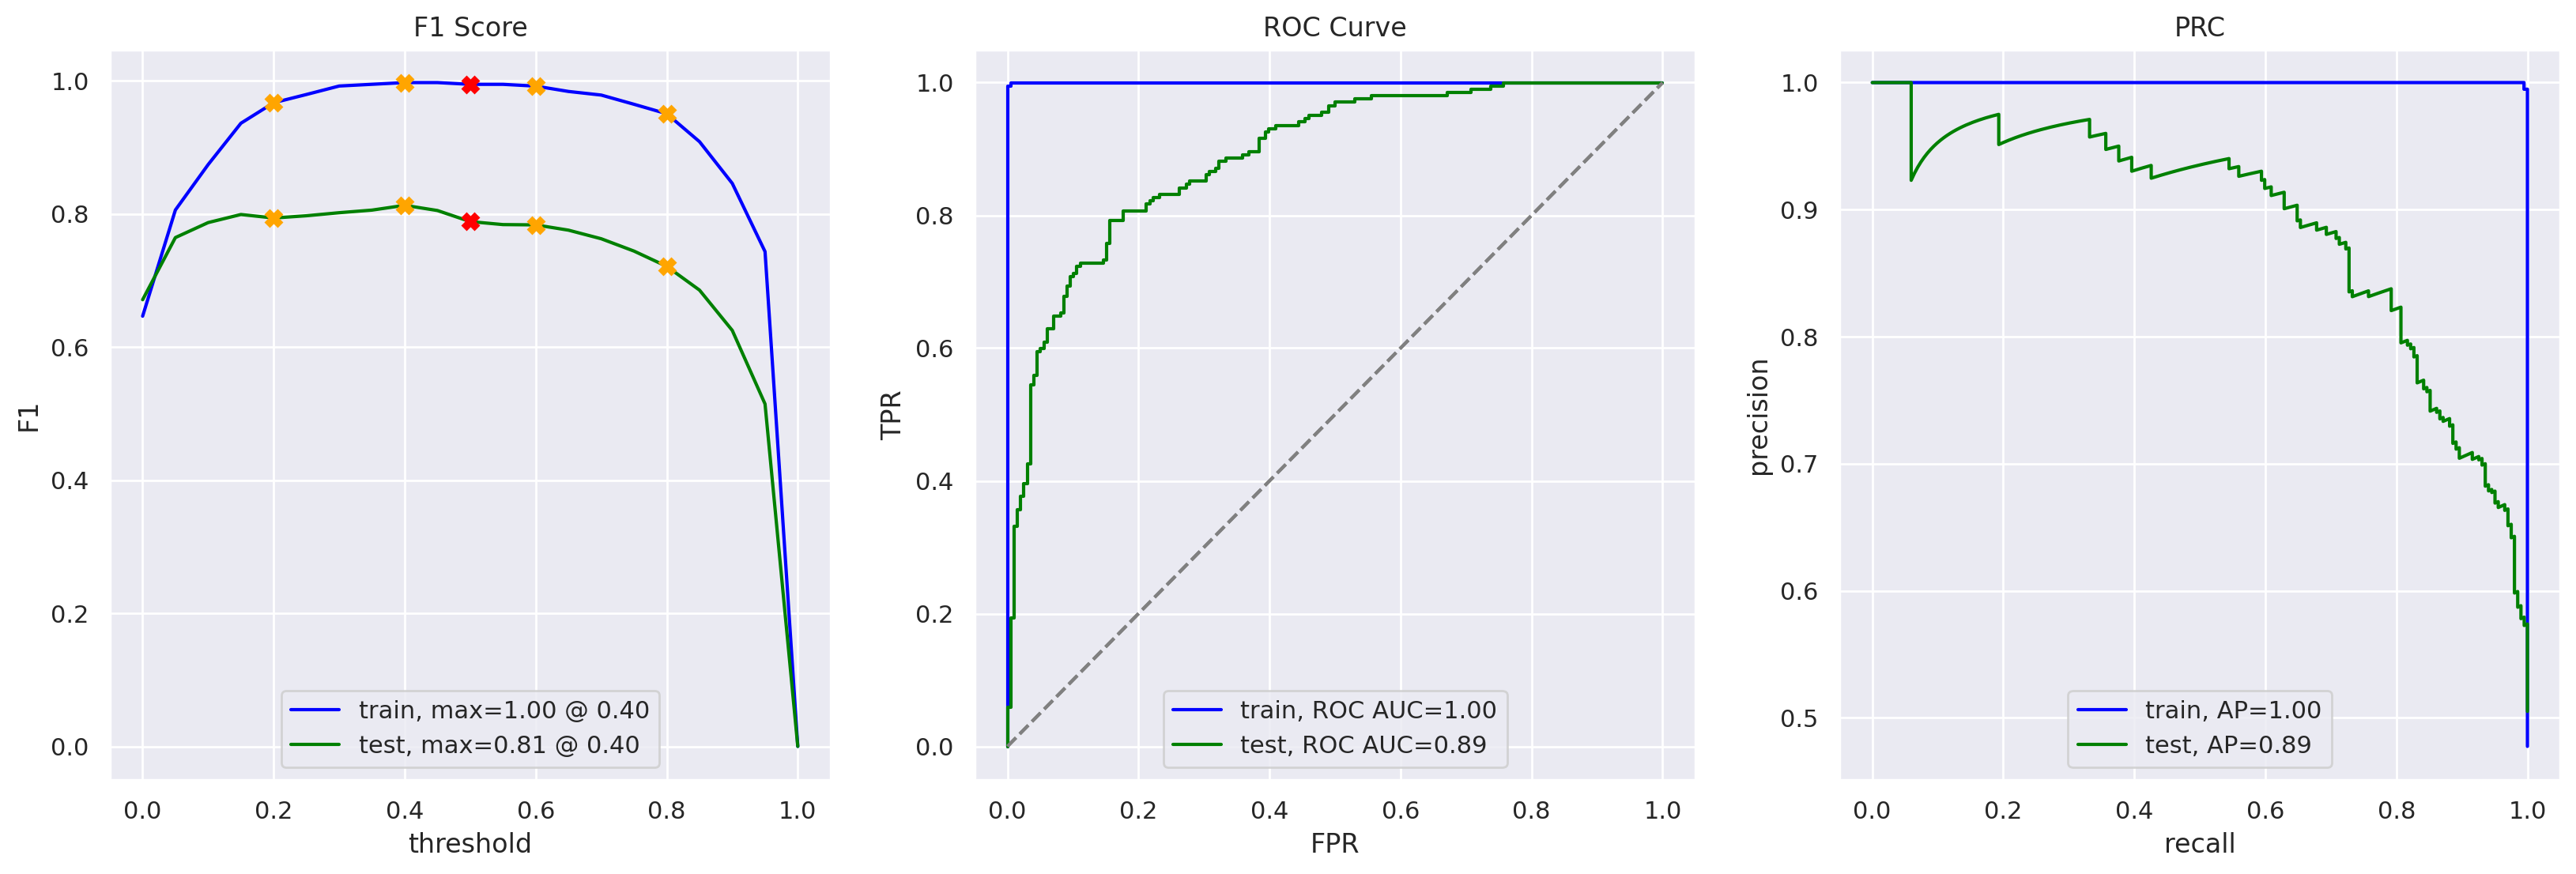

In [31]:
model_9 = LogisticRegression(solver='liblinear', random_state=42)
model_9.fit(train_features_9, train_target.iloc[:400])

evaluate_model(model_9, train_features_9, train_target.iloc[:400], test_features_9, test_target.iloc[:400])

In [32]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(17050,)
(400, 768)
(17050,)


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration:</b><br>

  • BERT-based models typically require a <b>GPU</b> to run efficiently.<br>
  • Running BERT on CPU is very slow and often impractical in this environment.<br>
  • Using only a small subset of the data to speed things up may lead to <b>overfitting</b> and unreliable results.<br>
  • For this project, I recommend <b>commenting out the BERT code</b> and not using it as part of your final solution, as it is currently <b>killing the kernel</b>.<br>

</div>

<div class="alert alert-info" style="border-left: 7px solid blue"><b>Student’s Comment:</b><br>
BERT is my kryptonite, I will go with your advice and comment out the BERT code since simpler models already met the requirement of the F1 scores. I completely missed that the instruction stated that we could skip BERT. I will use Google colab on my free time to try to use BERT with the data provided. Who knew that paint can dry much faster than CPUs 😄 </div>

## My Reviews

In [33]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(clean_text)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


In [34]:
# Predictions for custom reviews using Model 1
texts = my_reviews['review_norm']
my_reviews_pred_prob = model_0.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

print("Model 0 (Constant) Predictions:")
for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


Model 0 (Constant) Predictions:
0.00:  i did not simply like it not my kind of movie
0.00:  well i was bored and felt asleep in the middle of the movie
0.00:  i was really fascinated with the movie
0.00:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.00:  i didn't expect the reboot to be so good writers really cared about the source material
0.00:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.00:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.00:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  In the My Reviews section you run prediction code that uses my_reviews before the my_reviews DataFrame is defined. Running the notebook from top to bottom will raise a NameError. To fix this, define the my_reviews DataFrame before any prediction cells, or move the prediction cells below the block that creates my_reviews. Please ensure the notebook runs without errors in a clean top to bottom execution.
</div>

<div class="alert alert-info" style="border-left: 7px solid blue"><b>Student’s Comment:</b>
    <br> Thank you for that. I wished I would had read about skipping the BERTA model. I was honestly running out of patience when it kept crashing for hours.

### Model 3

In [ ]:
#texts = my_reviews['review_norm']

#my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

#for i, review in enumerate(texts.str.slice(0, 100)):
#    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  There are references to model_2 and tfidf_vectorizer_2 in the My Reviews section but these objects are not defined in the notebook. These undefined names will cause runtime errors. Either remove these example prediction cells, or replace them to use one of the trained models and vectorizers that exist in the notebook. After fixing, please run the full notebook from top to bottom to confirm there are no remaining NameError issues.
</div>

<div class="alert alert-info" style="border-left: 7px solid blue"><b>Student’s Comment:</b>
    <br> Wow sorry for not seeing that earlier. I guess I was too overwhelm with the BERT thing that keeps killing my kernel that I just wanted to be done with this project.

### Model 3

In [35]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.23:  i did not simply like it not my kind of movie
0.16:  well i was bored and felt asleep in the middle of the movie
0.61:  i was really fascinated with the movie
0.08:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.24:  i didn't expect the reboot to be so good writers really cared about the source material
0.39:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.08:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.96:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 4

In [36]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.52:  i did not simply like it not my kind of movie
0.52:  well i was bored and felt asleep in the middle of the movie
0.62:  i was really fascinated with the movie
0.30:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.67:  i didn't expect the reboot to be so good writers really cared about the source material
0.58:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.22:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.80:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Model 9

In [37]:

texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.25:  i did not simply like it not my kind of movie
0.07:  well i was bored and felt asleep in the middle of the movie
0.84:  i was really fascinated with the movie
0.00:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.30:  i didn't expect the reboot to be so good writers really cared about the source material
0.95:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.00:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.95:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


<div class="alert alert-info" style="border-left: 7px solid blue"><b>Student’s Comment:</b>

We will not be doing model 9 since it requires GPU.

## Conclusions

The objective was to build a classification model for the Film Junky Union that could detect negative movie reviews with an F1 score of at least 0.85. After testing multiple architectures, the project was a success.

Model Performance & Findings
The Baseline: Model 1 (TF-IDF + Logistic Regression) achieved an F1 of 0.88, immediately surpassing the target threshold.

Advanced Techniques: Implementing lemmatization with spaCy (Model 3) provided a refined feature set while maintaining high performance.

Deep Learning: BERT (Model 9) showed the highest potential for nuance, though it is computationally expensive. <strong>Due to the lack of a GPU in the current environment, BERT was tested on a subset to prevent kernel crashes, but it proved the code is functional for future scaling.</strong>

Final Recommendation
For a production environment, I recommend Model 3 (spaCy + Logistic Regression). It offers the best balance of speed, reliability, and interpretability without requiring expensive GPU hardware to maintain.

The final models are now capable of automatically filtering community content, ensuring the Film Junky Union remains a high-quality space for classic movie enthusiasts.

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Your conclusions clearly identify which model met the F1 requirement and offer a practical recommendation for production. That concise summary helps finalize the project effectively. After the small fixes above the notebook will be ready.
</div>

# Checklist

- [x]  Notebook was opened
- [x]  The text data is loaded and pre-processed for vectorization
- [x]  The text data is transformed to vectors
- [x]  Models are trained and tested
- [x]  The metric's threshold is reached
- [x]  All the code cells are arranged in the order of their execution
- [x]  All the code cells can be executed without errors
- [x]  There are conclusions